# XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy.stats import boxcox
import os
import pickle
from sklearn.model_selection import train_test_split
import pdb
import datetime
from scipy.stats import pearsonr
import warnings
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, log_loss, f1_score, precision_score, recall_score, roc_curve, roc_auc_score, auc
from sklearn.model_selection import  GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
import matplotlib
from pprint import pprint
from tqdm.notebook import tqdm


In [2]:
df=pd.read_csv(r'C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\Datos\df_ransomware1.csv')#copie la ruta y pegue donde tiene el archivo.

In [3]:
code = {False:0, True:1}
df['label'] = df['label'].map(code)
df.to_csv(r'C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\Datos\df_ransomware2.csv', index=False)
y = df['label']
X = df.drop('label',errors='ignore',axis=1)

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 9 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    object 
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
dtypes: float64(2), int64(6), object(1)
memory usage: 200.3+ MB


# Label encode

In [5]:
#convertir la columna de direcciones (categórica) a enteros
cat_types = ['bool','object','category']

X[X.select_dtypes(cat_types).columns] = X.select_dtypes(cat_types).apply(lambda x: x.astype('category'))
X['address_code']=X['address'].cat.codes
#X['year_code']=X['year'].cat.codes
code_address= X.select_dtypes(exclude=['int64', 'float64'])
X = X.drop(['address'],errors='ignore',axis=1)

# Normalización de variables numéricas

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Estandarizar features
scaler = MinMaxScaler()
# Estandarizar features
X = scaler.fit_transform(X)



# XGBoost

In [7]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto')
X_res, y_res = smote.fit_resample(X, y)

In [8]:
# Bucle de semillas para XGBoost con matriz de confusión y reporte por semilla
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

seeds = [0, 1, 7, 13, 21, 42, 73, 101, 123, 2024]
results = []

best_acc = -1.0
best_seed = None
# Estas variables se asignarán con el mejor modelo para reutilizar en celdas posteriores (ROC, importancia, etc.)
xgb_classifier = None
X_res_test = None
y_res_test = None

def build_xgb(seed: int) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=500,
        objective='binary:logistic',
        tree_method='hist',
        eta=0.1,
        max_depth=7,
        enable_categorical=True,
        random_state=seed
    )

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, stratify=y_res, random_state=seed
    )

    model = build_xgb(seed)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, digits=4)

    results.append({
        "seed": seed,
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": cr
    })

    print(f"\n==== XGBoost - Resultados para seed={seed} ====")
    print(f"Accuracy: {acc:.4f}")
    print("Matriz de confusión:")
    print(cm)
    print("\nReporte de clasificación:")
    print(cr)

    if acc > best_acc:
        best_acc = acc
        best_seed = seed
        # Publicamos el mejor para reutilizar en celdas posteriores
        xgb_classifier = model
        X_res_test = X_test
        y_res_test = y_test

print(f"\n>>> Mejor seed={best_seed} con accuracy={best_acc:.4f}")



==== XGBoost - Resultados para seed=0 ====
Accuracy: 0.9663
Matriz de confusión:
[[554247  20810]
 [ 17909 557148]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9687    0.9638    0.9662    575057
           1     0.9640    0.9689    0.9664    575057

    accuracy                         0.9663   1150114
   macro avg     0.9663    0.9663    0.9663   1150114
weighted avg     0.9663    0.9663    0.9663   1150114


==== XGBoost - Resultados para seed=1 ====
Accuracy: 0.9672
Matriz de confusión:
[[554768  20289]
 [ 17487 557570]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9694    0.9647    0.9671    575057
           1     0.9649    0.9696    0.9672    575057

    accuracy                         0.9672   1150114
   macro avg     0.9672    0.9672    0.9672   1150114
weighted avg     0.9672    0.9672    0.9672   1150114


==== XGBoost - Resultados para seed=7 ====
Accuracy: 0.96

## Curva ROC

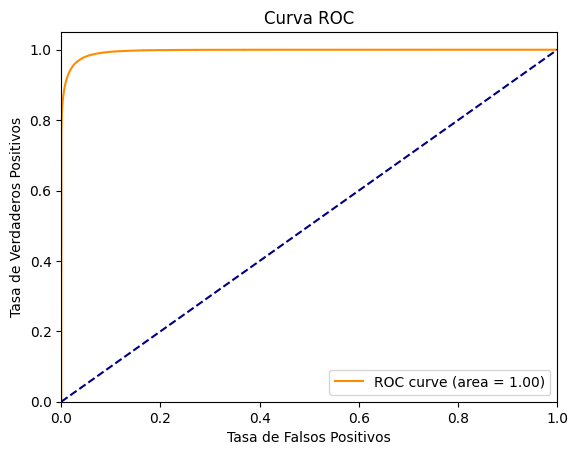

In [50]:
# Obtener las probabilidades de la clase positiva para los datos de prueba
y_prob = xgb_classifier.predict_proba(X_res_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_res_test, y_prob)

# Calcular el AUC
roc_auc = roc_auc_score(y_res_test, y_prob)

# Graficar la curva ROC
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\ROC_XGB.pdf", format='pdf')

## Importancia de las características

¿Cuáles son las características más importantes?

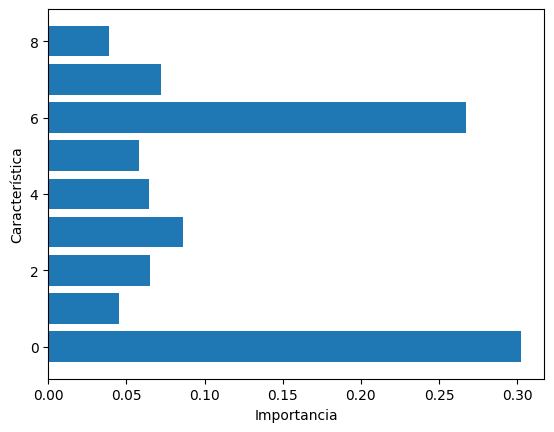

<Figure size 640x480 with 0 Axes>

In [51]:
# Calcular la importancia de las características
importances = xgb_classifier.feature_importances_

# Crear un DataFrame con las características y su importancia
X_res_train=pd.DataFrame(X_res_train)
feature_importances = pd.DataFrame({'feature': X_res_train.columns, 'importance': importances})

feature_importances.sort_values('importance', ascending=False, inplace=True)


# Visualizar los resultados
import matplotlib.pyplot as plt
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\importancia_variables.pdf", format='pdf')

## Curva de aprendizaje

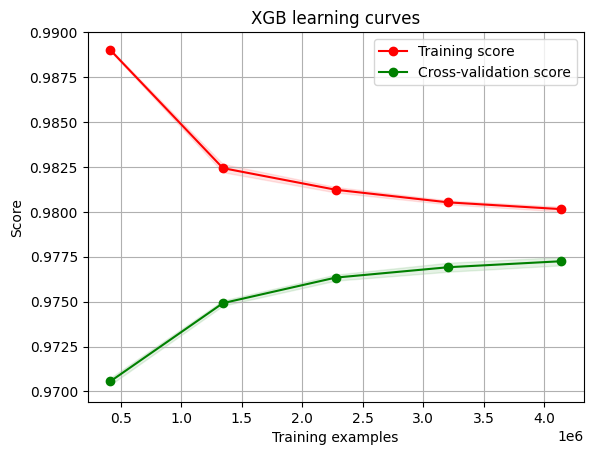

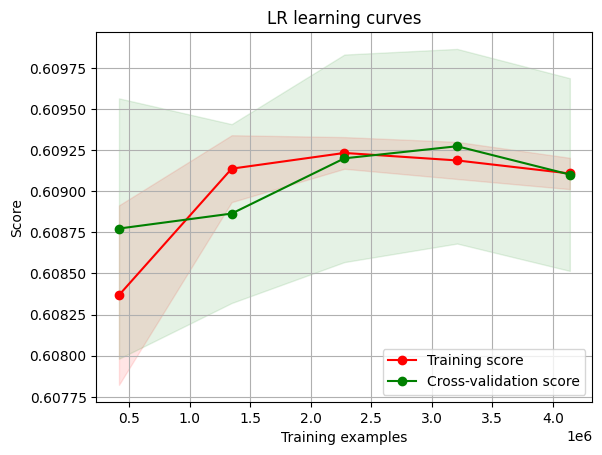

In [52]:
# Cross validate model with Kfold stratified cross val
kfold = StratifiedKFold(n_splits=10)
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

g = plot_learning_curve(grid_xgb.best_estimator_,"XGB learning curves",X_res_train,y_res_train,cv=kfold)
g.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\aprendizaje_xgb.pdf", format='pdf')
g = plot_learning_curve(grid.best_estimator_,"LR learning curves",X_res_train,y_res_train,cv=kfold)
g.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\aprendizaje_lr.pdf", format='pdf')